# Error Analysis

## Objective

This notebook investigates prediction errors produced by the trained anomaly detection model.

Main goals:

- Analyze False Positives
- Analyze False Negatives
- Investigate confidence scores
- Visualize difficult samples
- Understand model weaknesses
- Suggest future improvements

Industrial AI projects require not only high accuracy but also trustworthy predictions.

Error analysis helps engineers identify model limitations before deployment.

In [1]:
import numpy as np
import pandas as pd


from pathlib import Path

import joblib

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

import seaborn as sns

plt.style.use("ggplot")

In [2]:
PROJECT_ROOT = Path.cwd().parent

MODEL_PATH = PROJECT_ROOT/"models"/"best_model.pkl"

TEST_PATH = PROJECT_ROOT/"data"/"processed"/"test_data.csv"

RESULT_PATH = PROJECT_ROOT/"results"

RESULT_PATH.mkdir(exist_ok=True)

In [3]:
model = joblib.load(MODEL_PATH)

In [4]:
df_test = pd.read_csv(TEST_PATH)

X_test = df_test.drop(columns="Target")

y_test = df_test["Target"]

In [5]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:,1]

In [6]:
analysis = X_test.copy()

analysis["Actual"] = y_test.values

analysis["Prediction"] = y_pred

analysis["Probability"] = y_prob

In [7]:
conditions = [

    (analysis["Actual"]==0) & (analysis["Prediction"]==0),

    (analysis["Actual"]==0) & (analysis["Prediction"]==1),

    (analysis["Actual"]==1) & (analysis["Prediction"]==0),

    (analysis["Actual"]==1) & (analysis["Prediction"]==1)

]

choices = [

    "True Negative",

    "False Positive",

    "False Negative",

    "True Positive"

]

analysis["Result"] = np.select(
    conditions,
    choices,
    default="Unknown"
)

In [8]:
analysis["Result"].value_counts()

Result
True Negative     277190
True Positive      10918
False Positive       230
False Negative         6
Name: count, dtype: int64

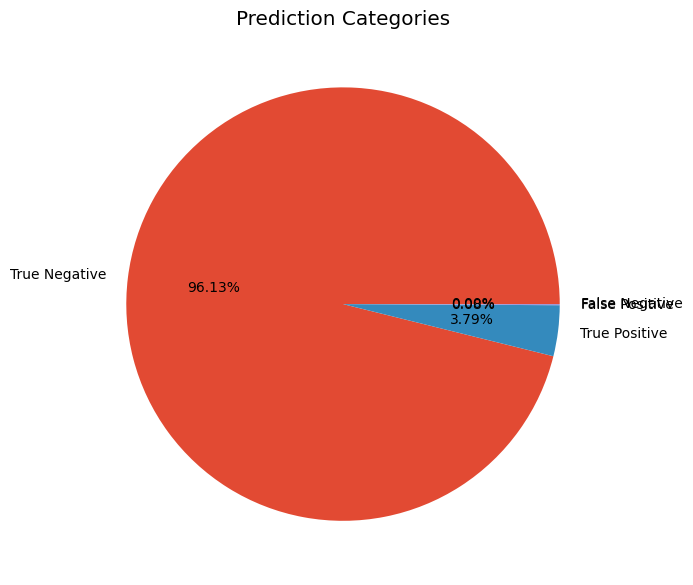

In [9]:
plt.figure(figsize=(7,7))

analysis["Result"].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%"
)

plt.ylabel("")

plt.title("Prediction Categories")

plt.tight_layout()

plt.savefig(

    RESULT_PATH/"prediction_categories.png",

    dpi=300

)

plt.show()

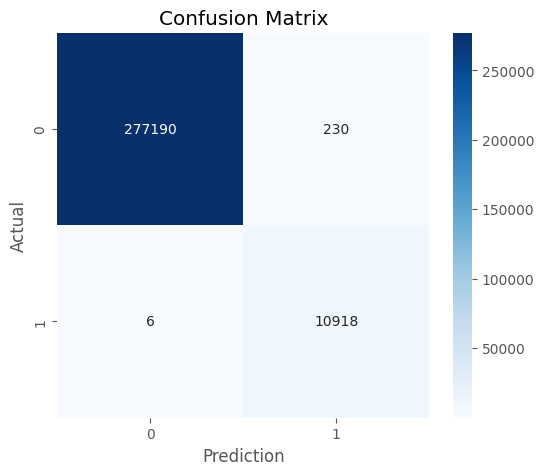

In [10]:
cm = confusion_matrix(

    y_test,

    y_pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Prediction")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.savefig(

    RESULT_PATH/"confusion_matrix_error_analysis.png",

    dpi=300

)

plt.show()

In [11]:
fp = analysis.query("Result=='False Positive'")

print(fp.shape)

fp.head()

(230, 55)


,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,PIT502,PIT503,FIT601,P601,P602,P603,Actual,Prediction,Probability,Result
956,0.554769,-0.667432,0.335952,0.606750,-0.046608,2.488366,-0.362240,-0.138349,0.612077,0.321655,...,1.353613,0.103853,-0.098181,0.0,-0.091453,0.0,0,1,0.550375,False Positive
3113,-1.565178,1.262703,-2.880775,-1.648125,-0.046608,3.063249,0.158529,-0.471604,-1.651437,-3.020295,...,1.833890,0.087624,-0.098181,0.0,-0.091453,0.0,0,1,0.667273,False Positive
3595,0.573087,-0.767201,0.335952,0.606750,-0.046608,-1.358351,1.609626,-0.810686,0.620466,0.321655,...,-0.567508,0.006472,-0.099023,0.0,-0.091453,0.0,0,1,0.648974,False Positive
3976,0.669953,-0.769734,0.335952,0.606750,-0.046608,-1.007963,1.460446,-0.782720,0.612786,0.321655,...,-0.407415,0.071392,-0.099023,0.0,-0.091453,0.0,0,1,0.584600,False Positive
4068,0.646361,-0.735845,0.335952,0.606750,-0.046608,-1.359871,1.615052,-0.811850,0.619048,0.321655,...,-0.567508,0.004307,-0.099023,0.0,-0.091453,0.0,0,1,0.654865,False Positive


In [12]:
fn = analysis.query("Result=='False Negative'")

print(fn.shape)

fn.head()

(6, 55)


,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,PIT502,PIT503,FIT601,P601,P602,P603,Actual,Prediction,Probability,Result
113030,-1.565178,1.777068,-2.880775,-1.648125,-0.046608,1.024609,1.194632,-0.512971,-1.651437,-3.020295,...,0.926696,0.120086,-0.098181,0.0,-0.091453,0.0,1,0,0.333658,False Negative
152614,0.539226,-0.752314,0.335952,-1.648125,21.455770,-1.042851,1.465872,-0.807191,0.601207,0.321655,...,-0.514144,0.062197,-0.099023,0.0,-0.091453,0.0,1,0,0.497191,False Negative
201632,0.723521,-0.602819,0.335952,0.606750,-0.046608,-0.995830,1.669293,-0.890504,0.619639,0.321655,...,-0.514144,0.103313,-0.099023,0.0,-0.091453,0.0,1,0,0.465297,False Negative
222623,-1.565178,0.568438,-2.880775,0.606750,21.455770,0.625680,0.022909,-0.193114,0.944196,0.321655,...,1.567071,-0.055746,-0.098181,0.0,-0.091453,0.0,1,0,0.306079,False Negative
240570,0.609169,1.065066,0.335952,-1.648125,-0.046608,-1.367455,2.271424,-1.096749,-1.651437,-3.020295,...,-2.115077,0.051918,-0.099023,0.0,-0.091453,0.0,1,0,0.407597,False Negative


In [13]:
fp.sort_values(

    "Probability",

    ascending=False

).head(20)

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,PIT502,PIT503,FIT601,P601,P602,P603,Actual,Prediction,Probability,Result
59969,0.674394,-0.742812,0.335952,0.60675,-0.046608,2.489881,-0.362240,-0.131358,0.611250,0.321655,...,1.513706,0.082755,-0.098181,0.0,-0.091453,0.0,0,1,0.918442,False Positive
243311,0.628043,-0.740279,0.335952,0.60675,-0.046608,3.054146,-0.524981,-0.201271,0.598489,0.321655,...,1.780526,0.086540,-0.098181,0.0,-0.091453,0.0,0,1,0.885543,False Positive
7290,0.593626,-0.735845,0.335952,0.60675,-0.046608,3.054146,-0.524981,-0.201271,0.598489,0.321655,...,1.780526,0.086540,-0.098181,0.0,-0.091453,0.0,0,1,0.881894,False Positive
84855,0.709088,-0.753581,0.335952,0.60675,-0.046608,2.907016,-0.226628,-0.190202,0.604752,0.321655,...,1.193519,0.163367,-0.098181,0.0,-0.091453,0.0,0,1,0.871967,False Positive
122293,0.715194,-0.746614,0.335952,0.60675,-0.046608,3.054146,-0.543967,-0.206514,0.601443,0.321655,...,1.993984,0.093574,-0.098181,0.0,-0.091453,0.0,0,1,0.866647,False Positive
168403,-1.565178,1.641826,-2.880775,0.60675,-0.046608,1.945332,0.014774,-0.022992,0.631572,0.321655,...,-3.769375,-1.599285,-0.099023,0.0,-0.091453,0.0,0,1,0.862998,False Positive
211317,0.731293,-0.754532,0.335952,0.60675,-0.046608,2.907016,-0.213060,-0.190202,0.606287,0.321655,...,1.193519,0.163367,-0.098181,0.0,-0.091453,0.0,0,1,0.860789,False Positive
273061,0.731293,-0.754532,0.335952,0.60675,-0.046608,2.907016,-0.213060,-0.190202,0.606287,0.321655,...,1.193519,0.163367,-0.098181,0.0,-0.091453,0.0,0,1,0.860789,False Positive
114819,0.751554,-0.753898,0.335952,0.60675,-0.046608,2.907016,-0.213060,-0.190202,0.606287,0.321655,...,1.193519,0.163367,-0.098181,0.0,-0.091453,0.0,0,1,0.855602,False Positive
201072,0.692990,-0.728243,0.335952,0.60675,-0.046608,3.054146,-0.524981,-0.205350,0.595890,0.321655,...,1.887255,0.084379,-0.098181,0.0,-0.091453,0.0,0,1,0.854890,False Positive


In [14]:
fn.sort_values(

    "Probability",

    ascending=True

).head(20)

,FIT101,LIT101,MV101,P101,P102,AIT201,AIT202,AIT203,FIT201,MV201,...,PIT502,PIT503,FIT601,P601,P602,P603,Actual,Prediction,Probability,Result
272895,-1.565178,0.571605,-2.880775,0.606750,21.455770,0.625680,0.022909,-0.193114,0.944196,0.321655,...,1.567071,-0.055746,-0.098181,0.0,-0.091453,0.0,1,0,0.182756,False Negative
222623,-1.565178,0.568438,-2.880775,0.606750,21.455770,0.625680,0.022909,-0.193114,0.944196,0.321655,...,1.567071,-0.055746,-0.098181,0.0,-0.091453,0.0,1,0,0.306079,False Negative
113030,-1.565178,1.777068,-2.880775,-1.648125,-0.046608,1.024609,1.194632,-0.512971,-1.651437,-3.020295,...,0.926696,0.120086,-0.098181,0.0,-0.091453,0.0,1,0,0.333658,False Negative
240570,0.609169,1.065066,0.335952,-1.648125,-0.046608,-1.367455,2.271424,-1.096749,-1.651437,-3.020295,...,-2.115077,0.051918,-0.099023,0.0,-0.091453,0.0,1,0,0.407597,False Negative
201632,0.723521,-0.602819,0.335952,0.606750,-0.046608,-0.995830,1.669293,-0.890504,0.619639,0.321655,...,-0.514144,0.103313,-0.099023,0.0,-0.091453,0.0,1,0,0.465297,False Negative
152614,0.539226,-0.752314,0.335952,-1.648125,21.455770,-1.042851,1.465872,-0.807191,0.601207,0.321655,...,-0.514144,0.062197,-0.099023,0.0,-0.091453,0.0,1,0,0.497191,False Negative


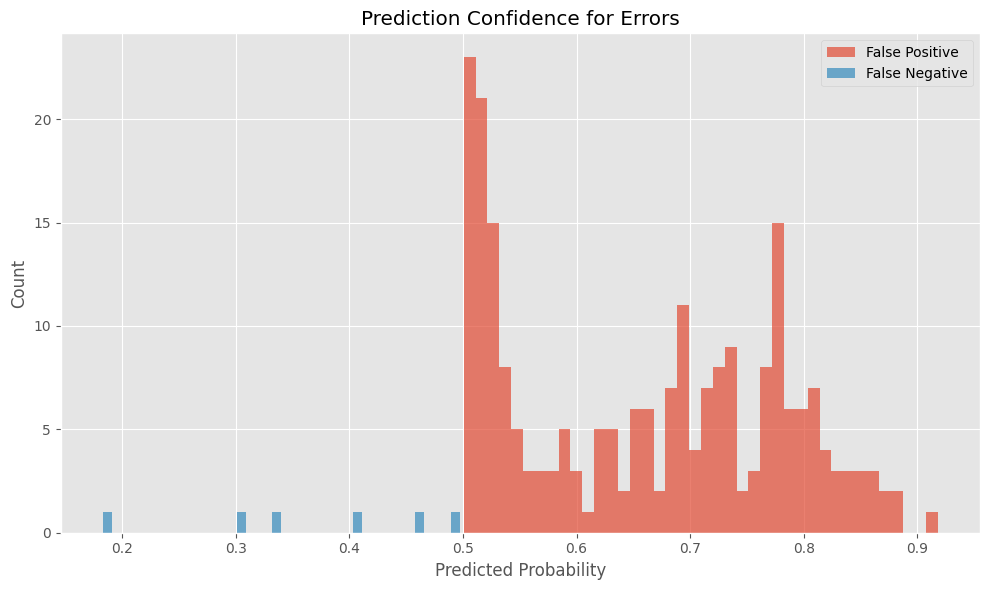

In [15]:
plt.figure(figsize=(10,6))

plt.hist(

    fp["Probability"],

    bins=40,

    alpha=.7,

    label="False Positive"

)

plt.hist(

    fn["Probability"],

    bins=40,

    alpha=.7,

    label="False Negative"

)

plt.legend()

plt.xlabel("Predicted Probability")

plt.ylabel("Count")

plt.title("Prediction Confidence for Errors")

plt.tight_layout()

plt.savefig(

    RESULT_PATH/"error_probability_distribution.png",

    dpi=300

)

plt.show()

In [16]:
fp.describe().T.sort_values(

    "std",

    ascending=False

).head(20)

,count,mean,std,min,25%,50%,75%,max
AIT504,230.0,0.619783,4.407293,-0.177986,-0.091891,-0.087107,-0.082324,30.106710
AIT202,230.0,-0.490454,2.775091,-20.584776,-0.543967,-0.516846,-0.226628,2.181919
AIT201,230.0,2.368461,1.333324,-1.364420,2.488366,3.054146,3.057180,3.069318
P201,230.0,0.052678,1.121651,-0.198155,-0.198155,-0.198155,-0.198155,5.046548
MV201,230.0,-0.012540,1.052192,-6.362245,0.321655,0.321655,0.321655,0.321655
PIT502,230.0,1.427626,0.908329,-3.769375,1.460342,1.620436,1.993984,2.314172
AIT503,230.0,-0.907222,0.863980,-3.703606,-1.122733,-0.749255,-0.721386,1.357817
LIT301,230.0,-0.130891,0.783159,-1.204031,-0.599788,-0.503510,0.253272,3.209357
FIT401,230.0,0.047369,0.765008,-4.256269,0.184415,0.197972,0.206854,0.233495
MV101,230.0,0.168123,0.716888,-2.880775,0.335952,0.335952,0.335952,0.335952


In [17]:
fn.describe().T.sort_values(

    "std",

    ascending=False

).head(20)

,count,mean,std,min,25%,50%,75%,max
P102,6.0,10.704581,11.777337,-0.046608,-0.046608,10.704581,21.455770,21.455770
P201,6.0,0.675962,2.141141,-0.198155,-0.198155,-0.198155,-0.198155,5.046548
MV304,6.0,1.158737,2.101289,-0.197640,-0.197640,-0.197640,2.854207,3.871489
MV101,6.0,-1.272411,1.761874,-2.880775,-2.880775,-1.272411,0.335952,0.335952
MV201,6.0,-0.792329,1.725775,-3.020295,-2.184808,0.321655,0.321655,0.321655
PIT502,6.0,0.152912,1.458227,-2.115077,-0.514144,0.206276,1.406977,1.567071
FIT201,6.0,-0.032273,1.263064,-1.651437,-1.088276,0.610423,0.863057,0.944196
P101,6.0,-0.520688,1.235046,-1.648125,-1.648125,-0.520688,0.606750,0.606750
FIT101,6.0,-0.470603,1.200490,-1.565178,-1.565178,-0.512976,0.591683,0.723521
P203,6.0,-0.139778,1.161555,-1.639339,-1.077003,0.610002,0.610002,0.610002


In [18]:
total = len(analysis)

errors = len(fp)+len(fn)

print(f"Total Samples : {total}")

print(f"Errors : {errors}")

print(f"Error Rate : {errors/total:.4%}")

Total Samples : 288344
Errors : 236
Error Rate : 0.0818%


In [20]:
analysis.to_csv(

    RESULT_PATH/"prediction_analysis.csv",

    index=False

)

fp.to_csv(

    RESULT_PATH/"false_positive.csv",

    index=False

)

fn.to_csv(

    RESULT_PATH/"false_negative.csv",

    index=False

)

# Conclusions

The trained anomaly detection model achieved a very low overall error rate.

Most industrial samples were classified correctly.

False Positives indicate situations where normal plant behavior was incorrectly classified as anomalous.

False Negatives are more critical because real attacks remain undetected.

Error investigation suggests that most difficult observations occur near the decision boundary where anomaly probability is close to 0.5.

This analysis demonstrates that the proposed model provides reliable predictions for industrial cyber-physical systems while highlighting scenarios requiring further investigation.

Future improvements may include:

- Threshold optimization
- Cost-sensitive learning
- Temporal sequence modeling
- Ensemble learning
- Online adaptation